# Hospital Performance Analysis (2023)

This notebook presents an end-to-end business analysis of hospital operations and revenue cycle performance. It consolidates the main analytical threads from the original exploratory work into one portfolio-ready flow: operational demand, service economics, payer and demographic context, revenue-cycle health, and actionable recommendations.

Source note: this notebook is the cleaned and consolidated portfolio version of the original archive notebooks.


In [1]:
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

warnings.filterwarnings("ignore")

plt.style.use("Solarize_Light2")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Resolve repository root whether the notebook is run from repo root or notebooks/
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").exists():
    REPO_ROOT = REPO_ROOT.parent

DB_PATH = (REPO_ROOT / "data" / "hospital.db").resolve()
engine = create_engine(f"sqlite:///{DB_PATH.as_posix()}", future=True)


## Data pipeline (CSV → SQLite)

This analysis reads from a reproducible SQLite database built from the CSV extracts in `data/`.

If you need to rebuild the database locally, run:

```bash
python scripts/build_sqlite_from_csv.py
```

The default output path is `data/hospital.db`.


In [2]:
# Unified helpers used across the notebook

def run_query(query: str, frame_name: str) -> pd.DataFrame:
    """Read SQL query output into a DataFrame and run a quick quality check."""
    df = pd.read_sql(query, con=engine)
    validate_dataframe(df, frame_name)
    return df


def validate_dataframe(df: pd.DataFrame, frame_name: str) -> None:
    """Run lightweight checks so each analysis step starts from trusted data."""
    missing_cells = int(df.isna().sum().sum())
    duplicate_rows = int(df.duplicated().sum())
    print(f"[{frame_name}] shape={df.shape}, missing_cells={missing_cells}, duplicate_rows={duplicate_rows}")


def show_df(df: pd.DataFrame, rows: int = 10) -> pd.DataFrame:
    """Keep DataFrame display consistent and easy to scan in portfolio output."""
    return df.head(rows)


def setup_plot(figsize=(10, 5), title=None, xlabel=None, ylabel=None, rotate_x=False):
    """Create a chart canvas with consistent labels and spacing."""
    fig, ax = plt.subplots(figsize=figsize)
    if title:
        ax.set_title(title, fontsize=13, pad=12)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    if rotate_x:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_ha("right")
    return fig, ax


def finalize_plot(ax):
    """Apply the same final style so visuals look consistent."""
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    plt.tight_layout()
    plt.show()


## Cleaning and Validation

Before moving to EDA, I run a minimal integrity check on core tables.

This step documents data trust assumptions clearly for portfolio reviewers.

In [3]:
# Why: quick table-level checks reduce the risk of building insights on broken joins.
core_tables = {
    "patients": "SELECT * FROM patients",
    "doctors": "SELECT * FROM doctors",
    "appointments": "SELECT * FROM appointments",
    "treatments": "SELECT * FROM treatments",
    "billing": "SELECT * FROM billing",
}

for table_name, table_query in core_tables.items():
    _ = run_query(table_query, frame_name=f"raw_{table_name}")

[raw_patients] shape=(50, 11), missing_cells=0, duplicate_rows=0
[raw_doctors] shape=(10, 8), missing_cells=0, duplicate_rows=0
[raw_appointments] shape=(200, 7), missing_cells=0, duplicate_rows=0
[raw_treatments] shape=(200, 6), missing_cells=0, duplicate_rows=0
[raw_billing] shape=(200, 7), missing_cells=0, duplicate_rows=0


## Overview

This section establishes hospital scale and baseline activity using core volume indicators (patients, doctors, and appointments).


In [4]:
query_data_scope = """
SELECT "Patients" AS entity, COUNT(*) AS total FROM patients
UNION ALL
SELECT "Doctors" AS entity, COUNT(*) AS total FROM doctors
UNION ALL
SELECT "Appointments" AS entity, COUNT(*) AS total FROM appointments
UNION ALL
SELECT "Treatments" AS entity, COUNT(*) AS total FROM treatments
UNION ALL
SELECT "Billing Records" AS entity, COUNT(*) AS total FROM billing;
"""
# Why: this baseline check verifies source table coverage before deeper analysis.
df_data_scope = run_query(query_data_scope, frame_name="df_data_scope")
show_df(df_data_scope)


[df_data_scope] shape=(5, 2), missing_cells=0, duplicate_rows=0


,entity,total
0,Patients,50
1,Doctors,10
2,Appointments,200
3,Treatments,200
4,Billing Records,200


The 2023 overview includes 50 patients, 10 doctors, and 200 appointments.
These baseline volumes frame staffing capacity, service demand, and downstream financial performance.


## Exploratory Data Analysis (EDA)

In this section, I analyze operational demand, patient mix, and provider capacity to explain performance patterns before moving to financial outcomes.

## Operational Deep-Dive

Focus: physician workload concentration, visit demand patterns, and service mix behavior that affect care delivery efficiency.


In [5]:
query_doctor_workload = """
SELECT
    d.doctor_id,
    d.first_name || " " || d.last_name AS doctor_name,
    d.specialization,
    COUNT(a.appointment_id) AS total_appointments,
    COUNT(DISTINCT a.patient_id) AS unique_patients
FROM doctors d
LEFT JOIN appointments a ON d.doctor_id = a.doctor_id
GROUP BY d.doctor_id, doctor_name, d.specialization
ORDER BY total_appointments DESC;
"""
# Why: workload concentration is a core driver for scheduling bottlenecks.
df_doctor_workload = run_query(query_doctor_workload, frame_name="df_doctor_workload")
show_df(df_doctor_workload)


[df_doctor_workload] shape=(10, 5), missing_cells=0, duplicate_rows=0


,doctor_id,doctor_name,specialization,total_appointments,unique_patients
0,D005,Sarah Taylor,Dermatology,29,23
1,D001,David Taylor,Dermatology,25,20
2,D006,Alex Davis,Pediatrics,24,19
3,D003,Jane Smith,Pediatrics,22,18
4,D002,Jane Davis,Pediatrics,21,17
5,D010,Linda Wilson,Oncology,19,12
6,D009,Sarah Smith,Pediatrics,17,15
7,D008,Linda Brown,Dermatology,16,12
8,D004,David Jones,Pediatrics,14,13
9,D007,Robert Davis,Oncology,13,12


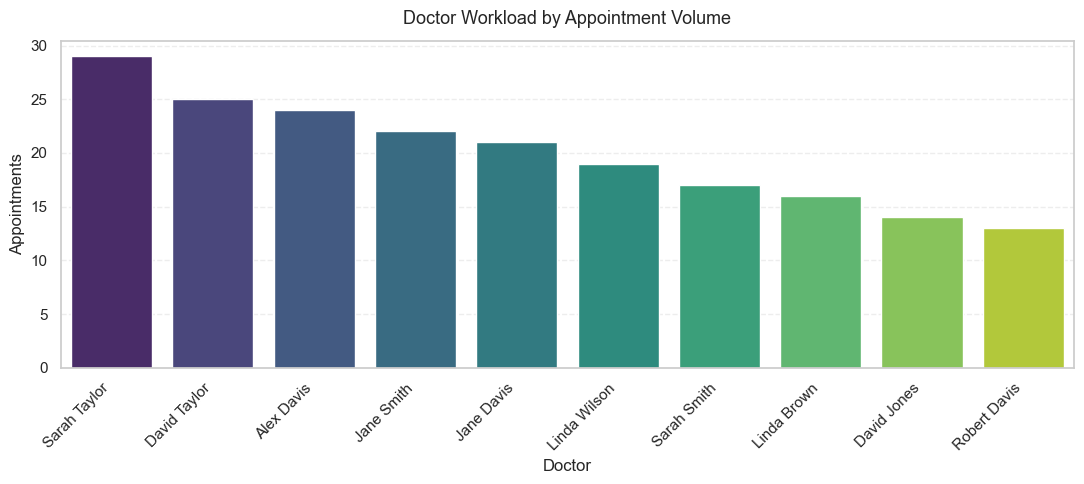

In [6]:
fig, ax = setup_plot(
    figsize=(11, 5),
    title="Doctor Workload by Appointment Volume",
    xlabel="Doctor",
    ylabel="Appointments",
    rotate_x=True
)
sns.barplot(data=df_doctor_workload, x="doctor_name", y="total_appointments", palette="viridis", ax=ax)
finalize_plot(ax)


**Insight:** Appointment demand is concentrated among a subset of doctors, suggesting scheduling imbalance and potential bottlenecks in patient flow.


In [7]:
query_doctor_revenue = """
SELECT
    d.first_name || " " || d.last_name AS doctor_name,
    d.specialization,
    SUM(b.amount) AS total_revenue,
    ROUND(AVG(t.cost), 2) AS avg_treatment_cost
FROM doctors d
JOIN appointments a ON d.doctor_id = a.doctor_id
JOIN treatments t ON a.appointment_id = t.appointment_id
JOIN billing b ON t.treatment_id = b.treatment_id
GROUP BY d.doctor_id, doctor_name, d.specialization
ORDER BY total_revenue DESC;
"""
# Why: linking physician activity to dollars helps explain workload-value imbalance.
df_doctor_revenue = run_query(query_doctor_revenue, frame_name="df_doctor_revenue")
show_df(df_doctor_revenue)


[df_doctor_revenue] shape=(10, 4), missing_cells=0, duplicate_rows=0


,doctor_name,specialization,total_revenue,avg_treatment_cost
0,Sarah Taylor,Dermatology,82696.48,2851.60
1,Alex Davis,Pediatrics,69586.10,2899.42
2,David Taylor,Dermatology,66585.39,2663.42
3,Jane Davis,Pediatrics,59803.46,2847.78
4,Linda Brown,Dermatology,53427.42,3339.21
5,Jane Smith,Pediatrics,52791.41,2399.61
6,Linda Wilson,Oncology,49436.23,2601.91
7,Robert Davis,Oncology,40166.50,3089.73
8,David Jones,Pediatrics,39315.95,2808.28
9,Sarah Smith,Pediatrics,37440.91,2202.41


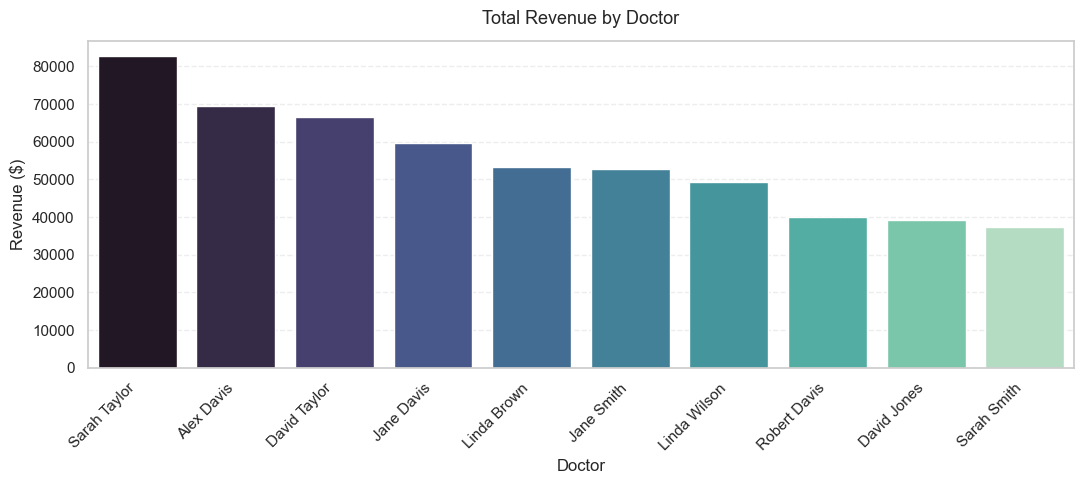

In [8]:
fig, ax = setup_plot(
    figsize=(11, 5),
    title="Total Revenue by Doctor",
    xlabel="Doctor",
    ylabel="Revenue ($)",
    rotate_x=True
)
sns.barplot(data=df_doctor_revenue, x="doctor_name", y="total_revenue", palette="mako", ax=ax)
finalize_plot(ax)


**Insight:** Revenue generation differs significantly across doctors, reflecting not only appointment volume but also treatment mix and case complexity.


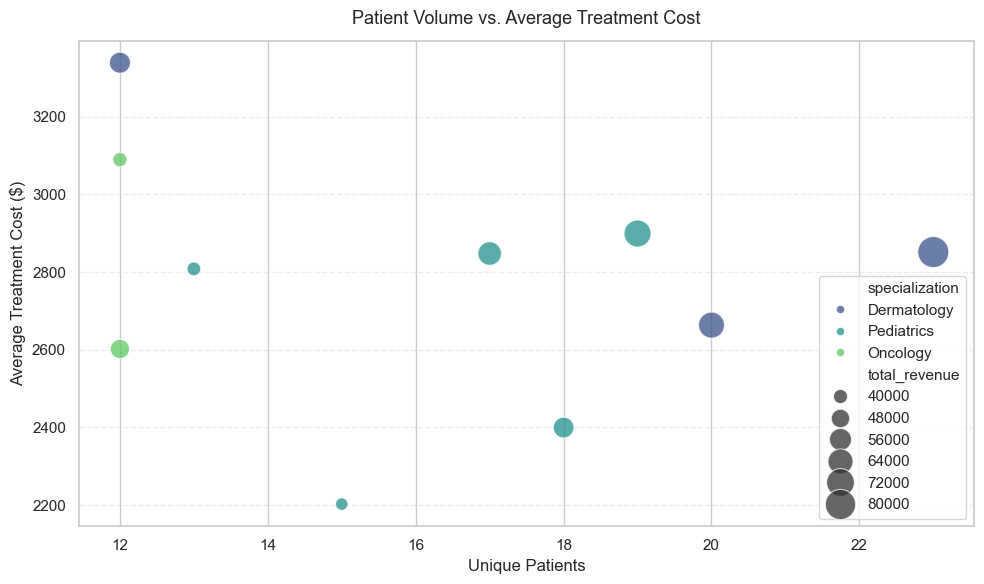

In [9]:
df_doctor_perf = df_doctor_workload.merge(
    df_doctor_revenue[["doctor_name", "specialization", "total_revenue", "avg_treatment_cost"]],
    on=["doctor_name", "specialization"],
    how="left"
).fillna(0)

fig, ax = setup_plot(
    figsize=(10, 6),
    title="Patient Volume vs. Average Treatment Cost",
    xlabel="Unique Patients",
    ylabel="Average Treatment Cost ($)"
)
sns.scatterplot(
    data=df_doctor_perf,
    x="unique_patients",
    y="avg_treatment_cost",
    hue="specialization",
    size="total_revenue",
    sizes=(80, 500),
    alpha=0.75,
    palette="viridis",
    ax=ax
)
finalize_plot(ax)


**Insight:** Distinct physician profiles emerge: some combine high patient volume with moderate cost, while others handle fewer but higher-cost cases.


### Operational Deep-Dive: Service Mix and Demand Drivers


In [10]:
query_treatment_mix = """
SELECT treatment_type, COUNT(*) AS total_treatments
FROM treatments
GROUP BY treatment_type
ORDER BY total_treatments DESC;
"""
# Why: treatment mix is a direct signal for demand planning and resource allocation.
df_treatment_mix = run_query(query_treatment_mix, frame_name="df_treatment_mix")
show_df(df_treatment_mix)


[df_treatment_mix] shape=(5, 2), missing_cells=0, duplicate_rows=0


,treatment_type,total_treatments
0,Chemotherapy,49
1,X-Ray,41
2,ECG,38
3,Physiotherapy,36
4,MRI,36


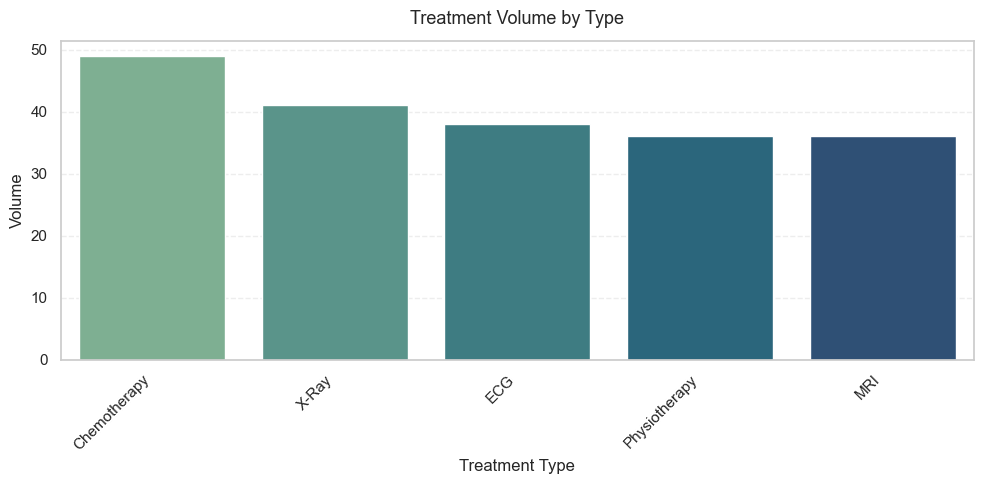

In [11]:
fig, ax = setup_plot(
    figsize=(10, 5),
    title="Treatment Volume by Type",
    xlabel="Treatment Type",
    ylabel="Volume",
    rotate_x=True
)
sns.barplot(data=df_treatment_mix, x="treatment_type", y="total_treatments", palette="crest", ax=ax)
finalize_plot(ax)


**Insight:** Treatment demand is distributed across multiple services, indicating a diversified care model rather than reliance on a single procedure type.


### Treatment Economics: Unit Cost and Revenue Share

Average unit cost and revenue concentration by treatment type inform pricing discipline and capacity planning (for example, high imaging cost vs. high-volume therapeutic services).


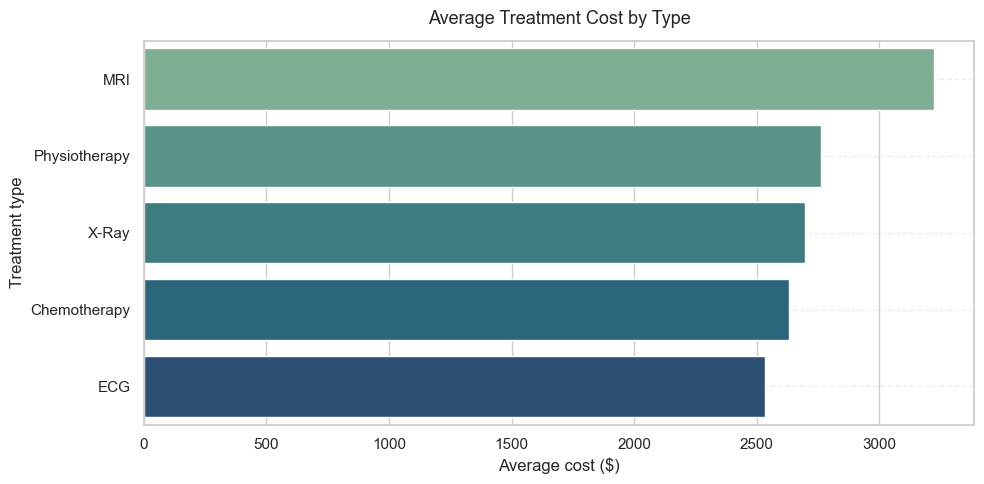

In [12]:
query_avg_treatment_cost = """
SELECT treatment_type, AVG(cost) AS avg_cost
FROM treatments
GROUP BY treatment_type
ORDER BY avg_cost DESC;
"""
# Why: average unit cost highlights where margin pressure can emerge first.
df_avg_cost_by_treatment = run_query(query_avg_treatment_cost, frame_name="df_avg_cost_by_treatment")
show_df(df_avg_cost_by_treatment)

fig, ax = setup_plot(
    figsize=(10, 5),
    title="Average Treatment Cost by Type",
    xlabel="Average cost ($)",
    ylabel="Treatment type",
)
sns.barplot(data=df_avg_cost_by_treatment, x="avg_cost", y="treatment_type", palette="crest", ax=ax)
finalize_plot(ax)


**Insight:** Procedure economics are not uniform: higher unit costs on some lines explain part of revenue volatility and should be paired with stronger pre-service financial counseling where needed.


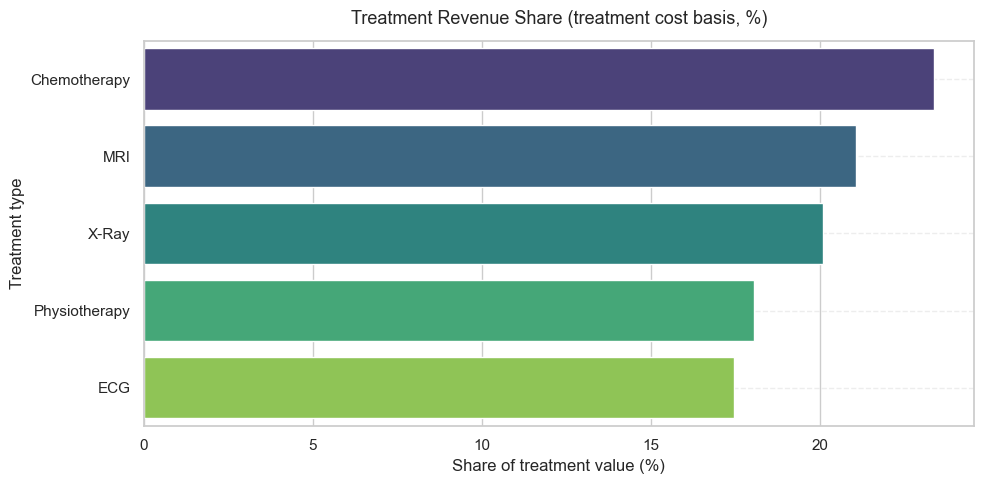

In [13]:
query_revenue_contribution = """
SELECT treatment_type, SUM(cost) AS total_revenue
FROM treatments
GROUP BY treatment_type
ORDER BY total_revenue DESC;
"""
# Why: revenue concentration helps prioritize which service lines need close monitoring.
df_revenue_by_treatment = run_query(query_revenue_contribution, frame_name="df_revenue_by_treatment")
df_revenue_by_treatment["revenue_pct"] = (
    df_revenue_by_treatment["total_revenue"] / df_revenue_by_treatment["total_revenue"].sum() * 100
)
show_df(df_revenue_by_treatment)

fig, ax = setup_plot(
    figsize=(10, 5),
    title="Treatment Revenue Share (treatment cost basis, %)",
    xlabel="Share of treatment value (%)",
    ylabel="Treatment type",
)
sns.barplot(data=df_revenue_by_treatment, x="revenue_pct", y="treatment_type", palette="viridis", ax=ax)
finalize_plot(ax)


**Insight:** A small number of treatment categories account for a large share of treatment value, which helps prioritize service-line investments and margin protection.


In [14]:
query_visit_reasons = """
SELECT reason_for_visit, COUNT(*) AS visits
FROM appointments
GROUP BY reason_for_visit
ORDER BY visits DESC
LIMIT 10;
"""
# Why: top visit reasons guide staffing templates and follow-up workflows.
df_visit_reasons = run_query(query_visit_reasons, frame_name="df_visit_reasons")
show_df(df_visit_reasons)


,reason_for_visit,visits
0,Checkup,45
1,Consultation,43
2,Therapy,42
3,Follow-up,41
4,Emergency,29


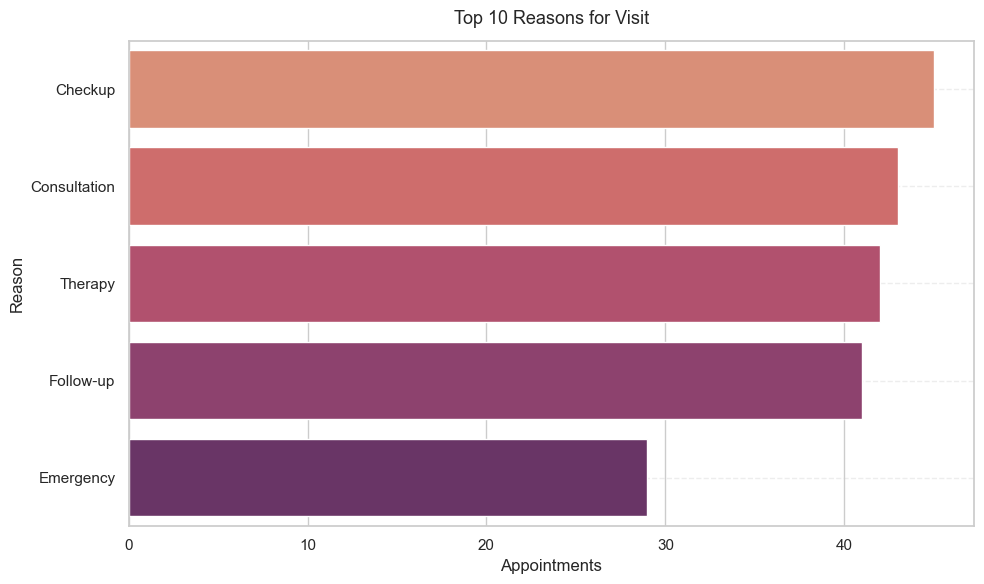

In [15]:
fig, ax = setup_plot(
    figsize=(10, 6),
    title="Top 10 Reasons for Visit",
    xlabel="Appointments",
    ylabel="Reason"
)
sns.barplot(data=df_visit_reasons, x="visits", y="reason_for_visit", palette="flare", ax=ax)
finalize_plot(ax)


**Insight:** Routine and follow-up visits dominate demand, which supports stable forecasting and proactive capacity management.


### Scheduling Outcomes and Monthly Operating Demand

Completion and no-show patterns affect utilization, while monthly volume shows where staffing and access need to flex.


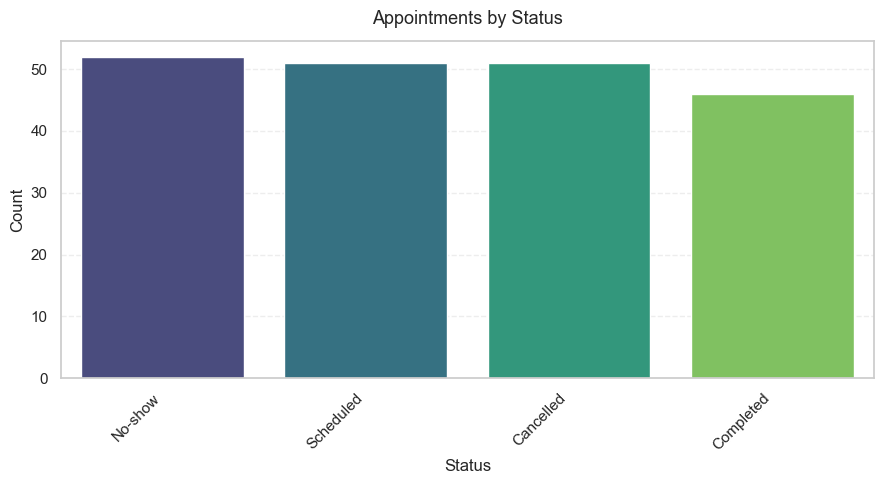

In [16]:
query_appointments_status = """
SELECT status, COUNT(*) AS total
FROM appointments
GROUP BY status
ORDER BY total DESC;
"""
# Why: completion status directly impacts both throughput and realized revenue.
df_appointments_status = run_query(query_appointments_status, frame_name="df_appointments_status")
show_df(df_appointments_status)

fig, ax = setup_plot(
    figsize=(9, 5),
    title="Appointments by Status",
    xlabel="Status",
    ylabel="Count",
    rotate_x=True,
)
sns.barplot(data=df_appointments_status, x="status", y="total", palette="viridis", ax=ax)
finalize_plot(ax)


**Insight:** A meaningful share of visits does not complete as scheduled; this is a direct lever for throughput and revenue if reminder and triage workflows improve.


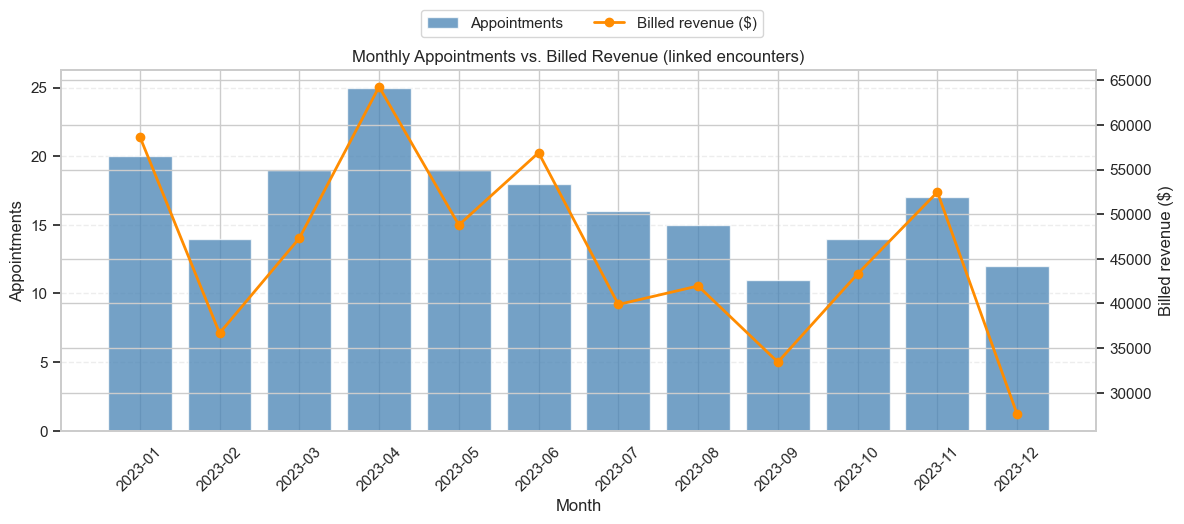

In [17]:
query_monthly_ops = """
SELECT
    strftime("%Y-%m", a.appointment_date) AS month,
    COUNT(a.appointment_id) AS total_appointments,
    SUM(b.amount) AS billed_revenue
FROM appointments a
LEFT JOIN treatments t ON a.appointment_id = t.appointment_id
LEFT JOIN billing b ON t.treatment_id = b.treatment_id
GROUP BY month
ORDER BY month;
"""
# Why: monthly operations trend ties workload behavior to financial movement.
df_monthly_ops = run_query(query_monthly_ops, frame_name="df_monthly_ops")
show_df(df_monthly_ops)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(df_monthly_ops["month"], df_monthly_ops["total_appointments"], color="steelblue", alpha=0.75, label="Appointments")
ax1.set_xlabel("Month")
ax1.set_ylabel("Appointments")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y", linestyle="--", alpha=0.35)

ax2 = ax1.twinx()
ax2.plot(
    df_monthly_ops["month"],
    df_monthly_ops["billed_revenue"],
    color="darkorange",
    marker="o",
    linewidth=2,
    label="Billed revenue ($)",
)
ax2.set_ylabel("Billed revenue ($)")

ax1.set_title("Monthly Appointments vs. Billed Revenue (linked encounters)")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.06), ncol=2)
plt.tight_layout()
plt.show()


**Insight:** Months with higher visit volume do not always move revenue proportionally, which highlights dependency on case mix and billing linkage—not just headcount in the schedule.


### Patient Demographics and Payer Concentration

Population mix and payer distribution shape access patterns and administrative workload (eligibility, authorizations, and collections).


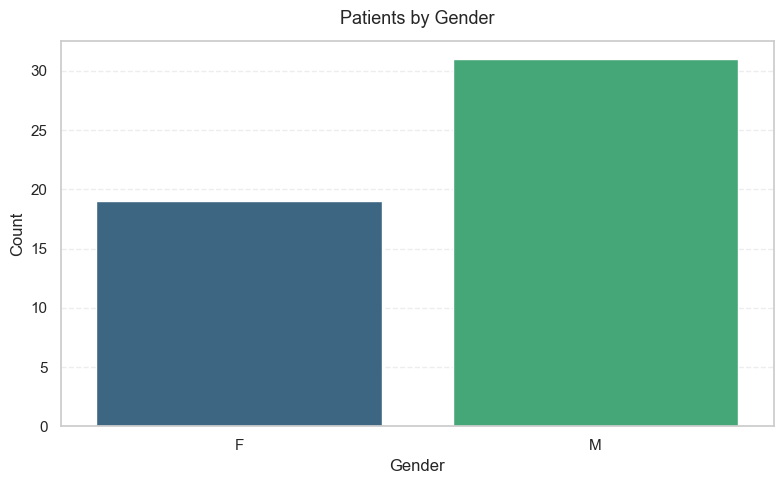

In [18]:
query_gender = """
SELECT gender, COUNT(*) AS total
FROM patients
GROUP BY gender;
"""
# Why: demographic balance helps explain demand pattern differences across services.
df_gender = run_query(query_gender, frame_name="df_gender")
show_df(df_gender)

fig, ax = setup_plot(figsize=(8, 5), title="Patients by Gender", xlabel="Gender", ylabel="Count")
sns.barplot(data=df_gender, x="gender", y="total", palette="viridis", ax=ax)
finalize_plot(ax)


**Insight:** Gender skew in the panel can influence demand for certain services and how outreach programs are designed.


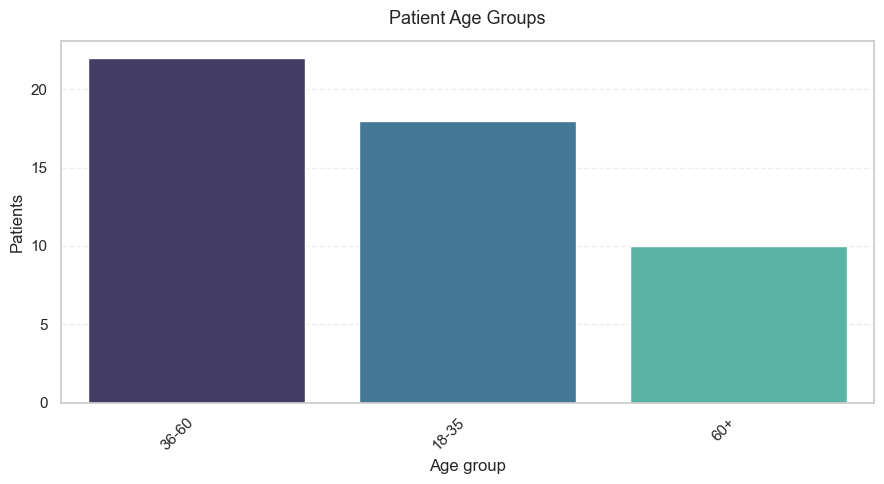

In [19]:
query_age_groups = """
SELECT
    CASE
        WHEN (strftime("%Y", "now") - strftime("%Y", date_of_birth)) < 18 THEN "Under 18"
        WHEN (strftime("%Y", "now") - strftime("%Y", date_of_birth)) BETWEEN 18 AND 35 THEN "18-35"
        WHEN (strftime("%Y", "now") - strftime("%Y", date_of_birth)) BETWEEN 36 AND 60 THEN "36-60"
        ELSE "60+"
    END AS age_group,
    COUNT(*) AS total_patients
FROM patients
GROUP BY age_group
ORDER BY total_patients DESC;
"""
# Why: age mix changes demand priorities and prevention strategy.
df_age_groups = run_query(query_age_groups, frame_name="df_age_groups")
show_df(df_age_groups)

fig, ax = setup_plot(
    figsize=(9, 5),
    title="Patient Age Groups",
    xlabel="Age group",
    ylabel="Patients",
    rotate_x=True,
)
sns.barplot(data=df_age_groups, x="age_group", y="total_patients", palette="mako", ax=ax)
finalize_plot(ax)


**Insight:** Working-age adults dominate the base, which typically elevates chronic-care and preventive pathways over pediatric-only demand.


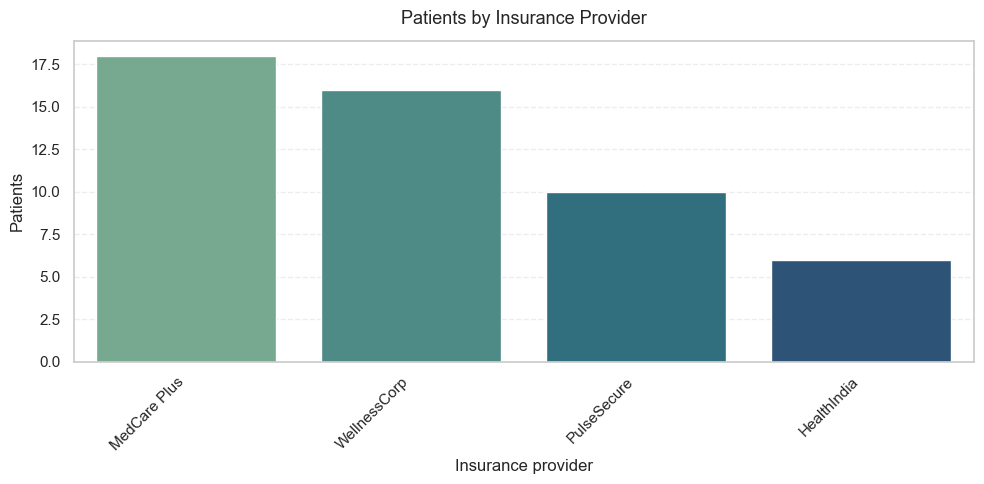

In [20]:
query_insurance = """
SELECT insurance_provider, COUNT(*) AS total_patients
FROM patients
GROUP BY insurance_provider
ORDER BY total_patients DESC;
"""
# Why: payer concentration is important for contract and collections risk.
df_insurance = run_query(query_insurance, frame_name="df_insurance")
show_df(df_insurance)

fig, ax = setup_plot(
    figsize=(10, 5),
    title="Patients by Insurance Provider",
    xlabel="Insurance provider",
    ylabel="Patients",
    rotate_x=True,
)
sns.barplot(data=df_insurance, x="insurance_provider", y="total_patients", palette="crest", ax=ax)
finalize_plot(ax)


**Insight:** Payer concentration simplifies operations but increases dependency on a few contracts—negotiation and denial patterns matter more when volume sits with limited payers.


### Staffing Footprint by Specialty and Site

Aligning physician supply with demand and understanding experience depth by site supports routing for complex cases and mentorship.


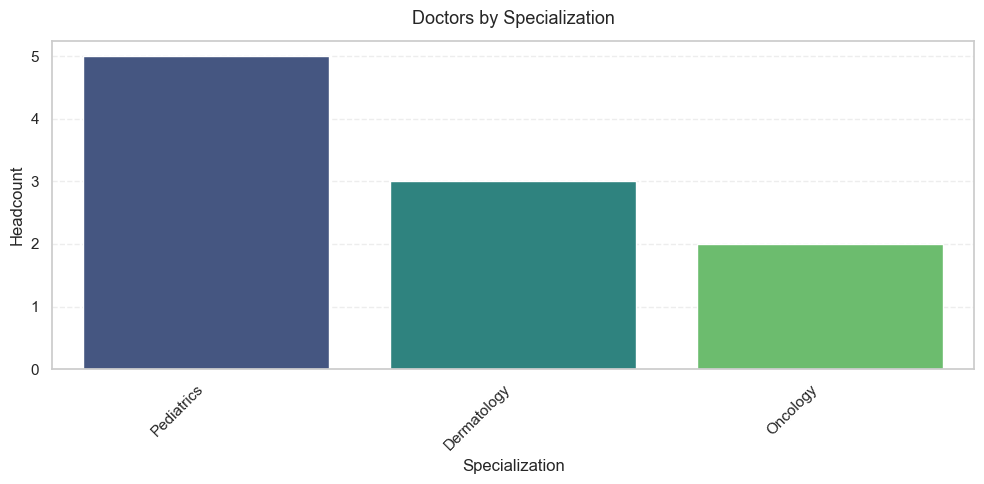

In [21]:
query_docs_by_spec = """
SELECT specialization, COUNT(*) AS total_doctors
FROM doctors
GROUP BY specialization
ORDER BY total_doctors DESC;
"""
# Why: specialty headcount is the supply side of the demand-supply equation.
df_docs_by_spec = run_query(query_docs_by_spec, frame_name="df_docs_by_spec")
show_df(df_docs_by_spec)

fig, ax = setup_plot(
    figsize=(10, 5),
    title="Doctors by Specialization",
    xlabel="Specialization",
    ylabel="Headcount",
    rotate_x=True,
)
sns.barplot(data=df_docs_by_spec, x="specialization", y="total_doctors", palette="viridis", ax=ax)
finalize_plot(ax)


**Insight:** The specialty mix shows where the organization is “heavy” or “light” relative to patient demand and revenue potential.


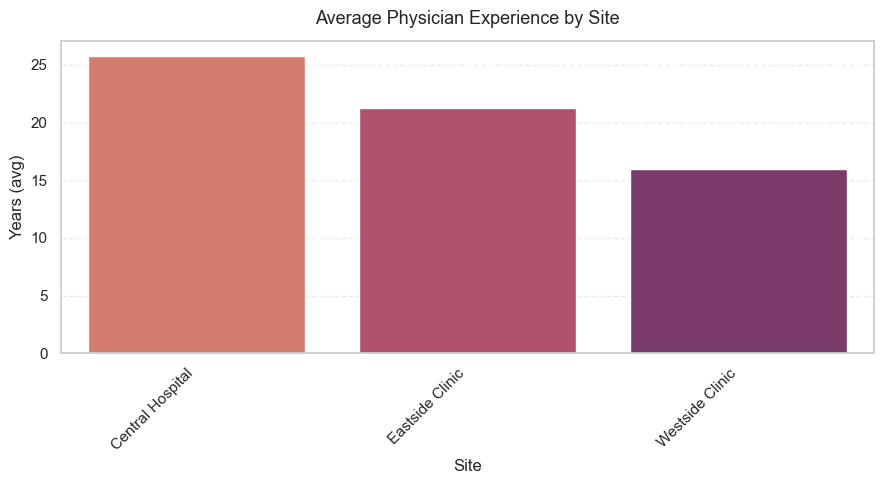

In [22]:
query_exp_by_branch = """
SELECT hospital_branch, ROUND(AVG(years_experience), 1) AS avg_years_experience
FROM doctors
GROUP BY hospital_branch
ORDER BY avg_years_experience DESC;
"""
# Why: experience distribution supports smarter routing of complex cases.
df_exp_branch = run_query(query_exp_by_branch, frame_name="df_exp_branch")
show_df(df_exp_branch)

fig, ax = setup_plot(
    figsize=(9, 5),
    title="Average Physician Experience by Site",
    xlabel="Site",
    ylabel="Years (avg)",
    rotate_x=True,
)
sns.barplot(data=df_exp_branch, x="hospital_branch", y="avg_years_experience", palette="flare", ax=ax)
finalize_plot(ax)


**Insight:** Experience depth varies by site; this is a practical input for where to route complex cases and where to invest in supervision.


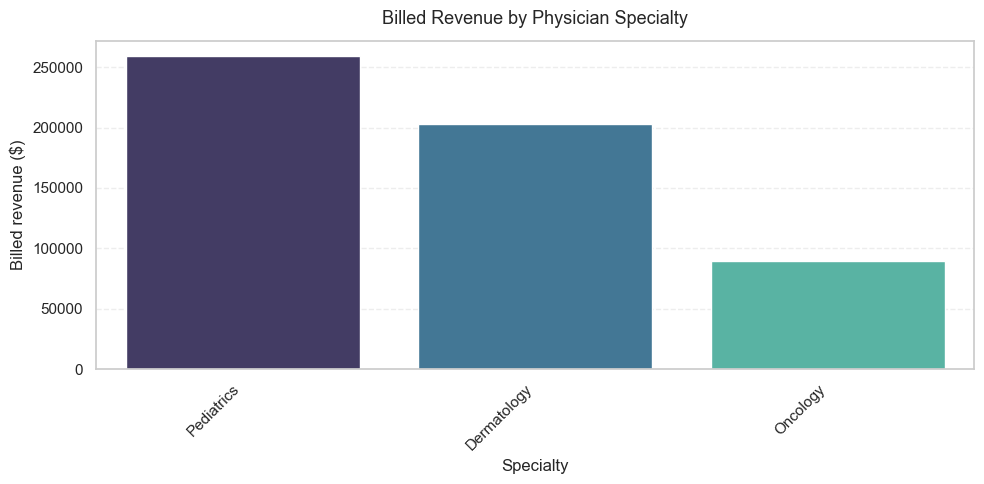

In [23]:
query_spec_billing_revenue = """
SELECT
    d.specialization,
    SUM(b.amount) AS total_billed_revenue
FROM billing b
JOIN treatments t ON b.treatment_id = t.treatment_id
JOIN appointments a ON t.appointment_id = a.appointment_id
JOIN doctors d ON a.doctor_id = d.doctor_id
GROUP BY d.specialization
ORDER BY total_billed_revenue DESC;
"""
# Why: this links financial outcomes to service-line structure.
df_spec_billing = run_query(query_spec_billing_revenue, frame_name="df_spec_billing")
show_df(df_spec_billing)

fig, ax = setup_plot(
    figsize=(10, 5),
    title="Billed Revenue by Physician Specialty",
    xlabel="Specialty",
    ylabel="Billed revenue ($)",
    rotate_x=True,
)
sns.barplot(data=df_spec_billing, x="specialization", y="total_billed_revenue", palette="mako", ax=ax)
finalize_plot(ax)


**Insight:** Specialty-level billed revenue shows which service lines anchor cash generation in the revenue cycle (not only clinical volume).


### New Patient Registrations Over Time

Registration inflows indicate market traction and onboarding workload for intake and billing setup.


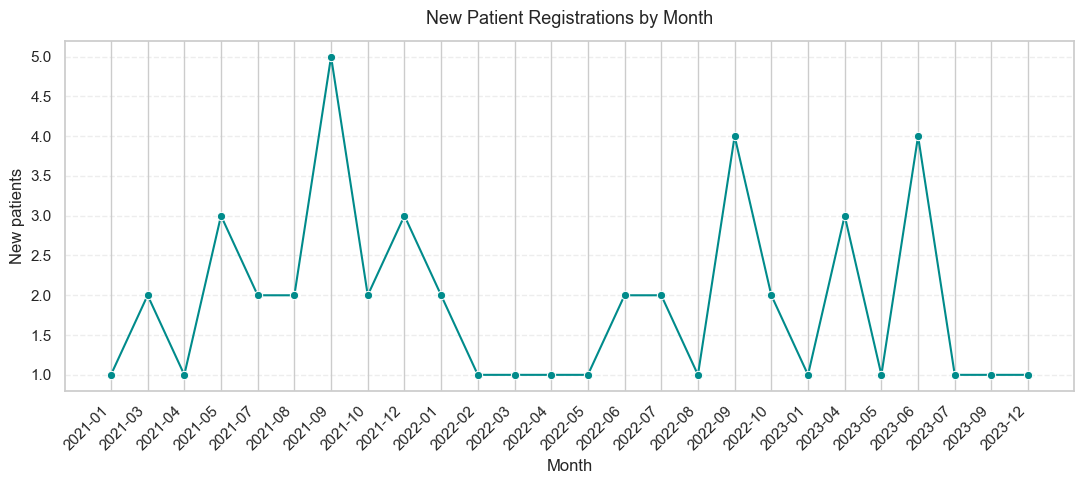

In [24]:
query_new_patients = """
WITH monthly_counts AS (
    SELECT
        strftime("%Y-%m", registration_date) AS month,
        COUNT(*) AS new_patients
    FROM patients
    GROUP BY month
)
SELECT
    month,
    new_patients,
    ROUND(
        (new_patients - LAG(new_patients) OVER (ORDER BY month)) * 100.0
        / NULLIF(LAG(new_patients) OVER (ORDER BY month), 0),
        2
    ) AS growth_rate_pct
FROM monthly_counts
ORDER BY month;
"""
# Why: acquisition trend supports planning for intake and billing onboarding load.
df_new_patients = run_query(query_new_patients, frame_name="df_new_patients")
show_df(df_new_patients)

fig, ax = setup_plot(
    figsize=(11, 5),
    title="New Patient Registrations by Month",
    xlabel="Month",
    ylabel="New patients",
    rotate_x=True,
)
sns.lineplot(data=df_new_patients, x="month", y="new_patients", marker="o", color="darkcyan", ax=ax)
finalize_plot(ax)


**Insight:** Acquisition is uneven month to month; operations and revenue teams should plan intake capacity around peaks while protecting billing setup quality.


## Financial Health

Focus: revenue quality, collection weakness, and treatment-cost variability with direct impact on cash flow.


In [25]:
query_financial_overview = """
SELECT
    SUM(amount) AS total_billed,
    SUM(CASE WHEN payment_status = "Paid" THEN amount ELSE 0 END) AS collected_amount,
    SUM(CASE WHEN payment_status IN ("Pending", "Failed", "Unpaid") THEN amount ELSE 0 END) AS outstanding_amount,
    ROUND(SUM(CASE WHEN payment_status = "Paid" THEN amount ELSE 0 END) * 100.0 / SUM(amount), 2) AS collection_rate_percent
FROM billing;
"""
# Why: this snapshot establishes the top-level liquidity position before trend analysis.
df_financial_overview = run_query(query_financial_overview, frame_name="df_financial_overview")
show_df(df_financial_overview)


[df_financial_overview] shape=(1, 4), missing_cells=0, duplicate_rows=0


,total_billed,collected_amount,outstanding_amount,collection_rate_percent
0,551249.85,173424.90,377824.95,31.46


### Billed Dollars by Payment Status

This view complements invoice-mix charts by showing where dollars sit across paid vs. non-paid states - the core liquidity story for leadership.


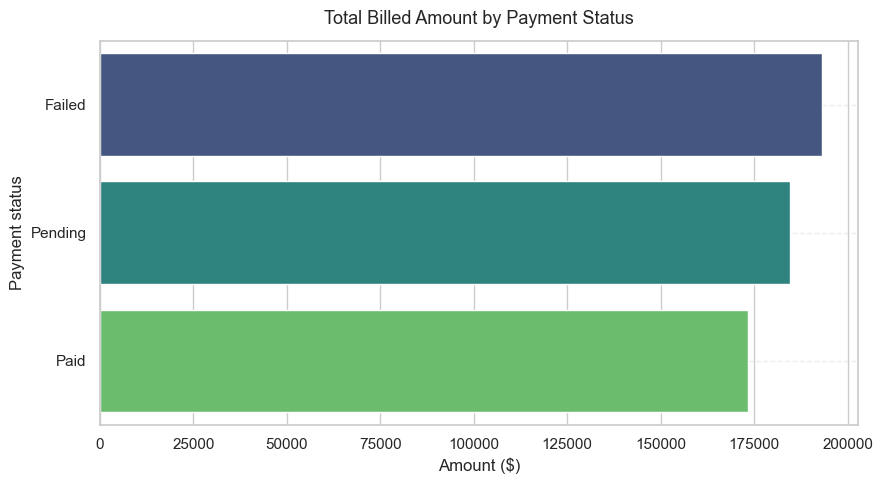

In [26]:
query_billed_by_status = """
SELECT payment_status, SUM(amount) AS total_amount
FROM billing
GROUP BY payment_status
ORDER BY total_amount DESC;
"""
# Why: dollar mix by status shows where cash is locked.
df_billed_by_status = run_query(query_billed_by_status, frame_name="df_billed_by_status")
show_df(df_billed_by_status)

fig, ax = setup_plot(
    figsize=(9, 5),
    title="Total Billed Amount by Payment Status",
    xlabel="Amount ($)",
    ylabel="Payment status",
)
sns.barplot(data=df_billed_by_status, x="total_amount", y="payment_status", palette="viridis", ax=ax)
finalize_plot(ax)


**Insight:** Non-paid statuses hold a large dollar balance, which explains cash pressure even when operational throughput looks healthy.


### Revenue Concentration by Payment Method

Payment rails highlight operational dependencies (card vs. insurance vs. cash) and where process friction is most likely.


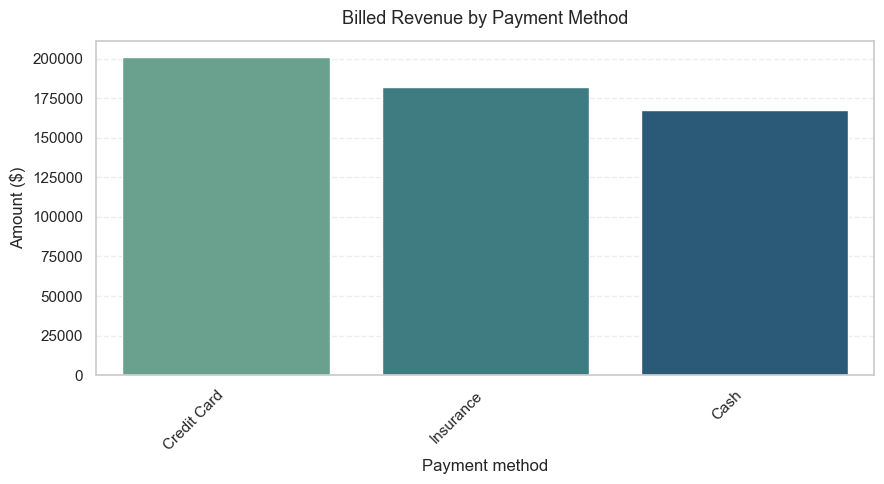

In [27]:
query_revenue_by_method = """
SELECT payment_method, SUM(amount) AS total_revenue
FROM billing
GROUP BY payment_method
ORDER BY total_revenue DESC;
"""
# Why: payment-method mix points to operational dependency and lag behavior.
df_pay_method = run_query(query_revenue_by_method, frame_name="df_pay_method")
show_df(df_pay_method)

fig, ax = setup_plot(
    figsize=(9, 5),
    title="Billed Revenue by Payment Method",
    xlabel="Payment method",
    ylabel="Amount ($)",
    rotate_x=True,
)
sns.barplot(data=df_pay_method, x="payment_method", y="total_revenue", palette="crest", ax=ax)
finalize_plot(ax)


**Insight:** The organization’s cash posture is influenced not only by collections discipline but also by the mix of payment rails and their typical lag behaviors.


In [28]:
query_monthly_collection = """
SELECT
    strftime("%Y-%m", bill_date) AS month,
    SUM(amount) AS total_billed,
    SUM(CASE WHEN payment_status = "Paid" THEN amount ELSE 0 END) AS collected_amount,
    SUM(CASE WHEN payment_status IN ("Pending", "Failed", "Unpaid") THEN amount ELSE 0 END) AS outstanding_amount,
    ROUND(SUM(CASE WHEN payment_status = "Paid" THEN amount ELSE 0 END) * 100.0 / SUM(amount), 2) AS collection_rate_percent
FROM billing
GROUP BY month
ORDER BY month;
"""
# Why: monthly trend helps identify whether collection weakness is structural or temporary.
df_monthly_collection = run_query(query_monthly_collection, frame_name="df_monthly_collection")
show_df(df_monthly_collection)


[df_monthly_collection] shape=(12, 5), missing_cells=0, duplicate_rows=0


,month,total_billed,collected_amount,outstanding_amount,collection_rate_percent
0,2023-01,58701.23,20080.64,38620.59,34.21
1,2023-02,36669.69,3032.56,33637.13,8.27
2,2023-03,47304.29,19595.74,27708.55,41.42
3,2023-04,64271.54,10379.73,53891.81,16.15
4,2023-05,48791.05,12892.05,35899.00,26.42
5,2023-06,56887.82,30474.04,26413.78,53.57
6,2023-07,39880.19,7638.12,32242.07,19.15
7,2023-08,41958.67,11837.58,30121.09,28.21
8,2023-09,33426.53,16204.43,17222.10,48.48
9,2023-10,43314.15,15708.52,27605.63,36.27


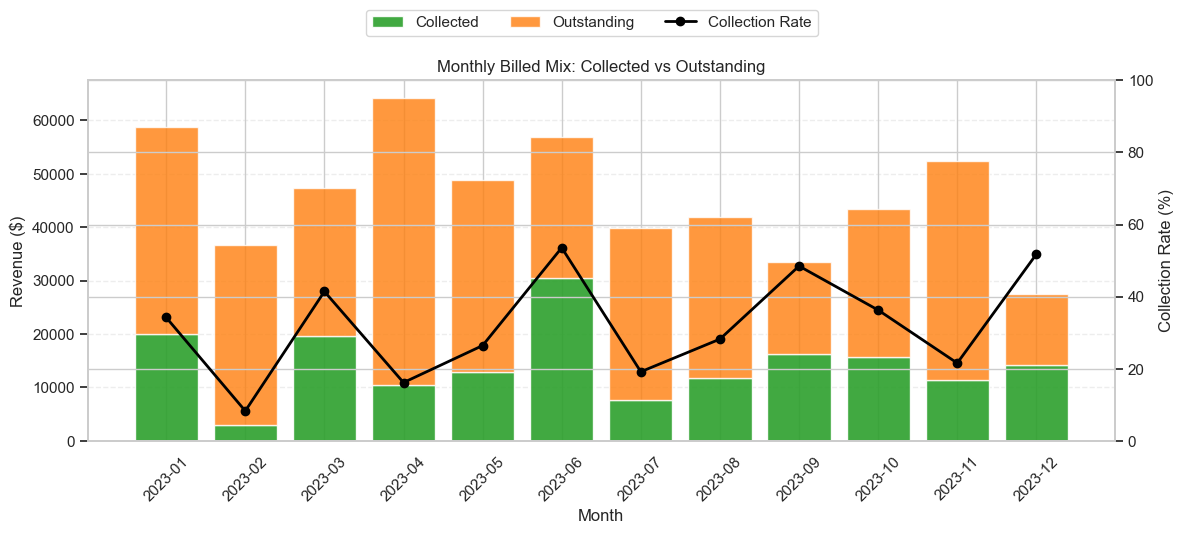

In [29]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(df_monthly_collection["month"], df_monthly_collection["collected_amount"], color="#2ca02c", alpha=0.9, label="Collected")
ax1.bar(
    df_monthly_collection["month"],
    df_monthly_collection["outstanding_amount"],
    bottom=df_monthly_collection["collected_amount"],
    color="#ff7f0e",
    alpha=0.8,
    label="Outstanding",
)
ax1.set_title("Monthly Billed Mix: Collected vs Outstanding")
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue ($)")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y", linestyle="--", alpha=0.35)

ax2 = ax1.twinx()
ax2.plot(df_monthly_collection["month"], df_monthly_collection["collection_rate_percent"], color="black", marker="o", linewidth=2, label="Collection Rate")
ax2.set_ylabel("Collection Rate (%)")
ax2.set_ylim(0, 100)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
fig.legend(handles1 + handles2, labels1 + labels2, loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=3)
plt.tight_layout()
plt.show()


**Insight:** Collection performance remains the main financial weakness: the paid share is consistently below potential, creating recurring pressure on cash flow.


In [30]:
query_payment_status = """
SELECT
    payment_status,
    COUNT(*) AS invoices,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM billing), 1) AS share_percent
FROM billing
GROUP BY payment_status
ORDER BY invoices DESC;
"""
# Why: invoice share confirms whether non-payment is a broad or narrow issue.
df_payment_status = run_query(query_payment_status, frame_name="df_payment_status")
show_df(df_payment_status)


,payment_status,invoices,share_percent
0,Pending,69,34.50
1,Failed,67,33.50
2,Paid,64,32.00


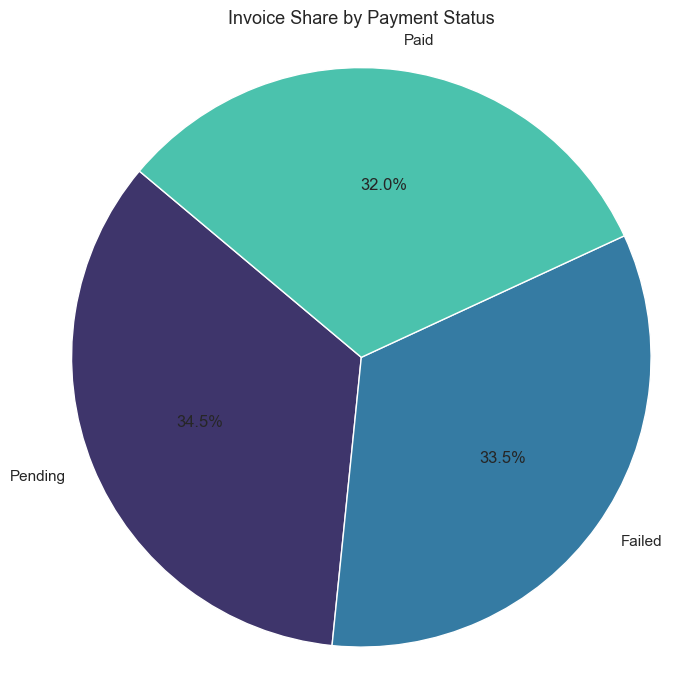

In [31]:
fig, ax = setup_plot(figsize=(7, 7), title="Invoice Share by Payment Status")
ax.pie(
    df_payment_status["share_percent"],
    labels=df_payment_status["payment_status"],
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("mako", len(df_payment_status)),
)
ax.axis("equal")
plt.tight_layout()
plt.show()


**Insight:** Non-paid invoices (Pending/Failed/Unpaid) represent the majority of billing records, confirming a structural collection problem rather than isolated delays.


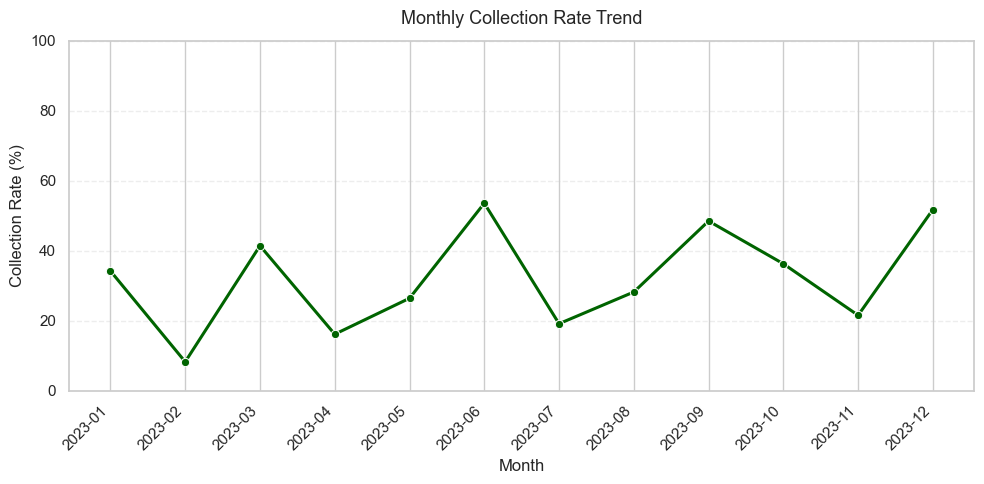

In [32]:
fig, ax = setup_plot(
    figsize=(10, 5),
    title="Monthly Collection Rate Trend",
    xlabel="Month",
    ylabel="Collection Rate (%)",
    rotate_x=True
)
sns.lineplot(data=df_monthly_collection, x="month", y="collection_rate_percent", marker="o", color="darkgreen", linewidth=2.2, ax=ax)
ax.set_ylim(0, 100)
finalize_plot(ax)


**Insight:** Collection rate volatility across months indicates that billing recovery is inconsistent and operational follow-up is not yet standardized.


### Financial Health: Patient and Revenue Composition


In [33]:
query_patient_net = """
SELECT
    p.patient_id,
    p.first_name || " " || p.last_name AS patient_name,
    SUM(CASE WHEN b.payment_status = "Paid" THEN b.amount ELSE 0 END) AS paid_revenue,
    SUM(CASE WHEN b.payment_status IN ("Pending", "Failed", "Unpaid") THEN b.amount ELSE 0 END) AS unpaid_amount,
    SUM(CASE WHEN b.payment_status = "Paid" THEN b.amount ELSE 0 END)
      - SUM(CASE WHEN b.payment_status IN ("Pending", "Failed", "Unpaid") THEN b.amount ELSE 0 END) AS net_revenue
FROM billing b
JOIN patients p ON b.patient_id = p.patient_id
GROUP BY p.patient_id, patient_name
ORDER BY net_revenue DESC;
"""
# Why: patient-level net view highlights value concentration and risk concentration together.
df_patient_net = run_query(query_patient_net, frame_name="df_patient_net")
show_df(df_patient_net)


,patient_id,patient_name,paid_revenue,unpaid_amount,net_revenue
0,P007,Alex Johnson,8636.90,2097.48,6539.42
1,P048,Emily Miller,11711.41,5371.07,6340.34
2,P024,Sarah Brown,7506.58,2970.12,4536.46
3,P010,Michael Taylor,10099.15,5830.00,4269.15
4,P032,Alex Moore,8698.50,4958.17,3740.33
5,P035,David Wilson,10424.42,7983.00,2441.42
6,P038,David Smith,4846.20,2691.78,2154.42
7,P003,Laura Jones,4704.96,3231.92,1473.04
8,P012,Laura Davis,15629.88,14423.20,1206.68
9,P049,David Moore,12149.85,11404.21,745.64


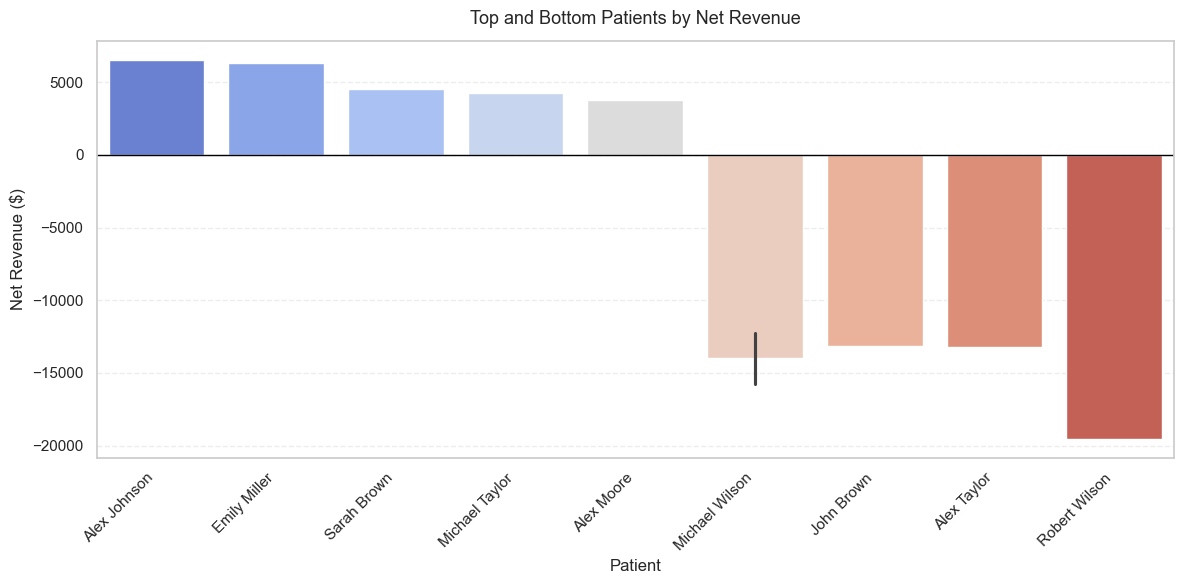

In [34]:
top5 = df_patient_net.head(5).copy()
bottom5 = df_patient_net.tail(5).copy()
plot_df = pd.concat([top5, bottom5], axis=0)

fig, ax = setup_plot(
    figsize=(12, 6),
    title="Top and Bottom Patients by Net Revenue",
    xlabel="Patient",
    ylabel="Net Revenue ($)",
    rotate_x=True
)
sns.barplot(data=plot_df, x="patient_name", y="net_revenue", palette="coolwarm", ax=ax)
ax.axhline(0, color="black", linewidth=1)
finalize_plot(ax)


**Insight:** Patient-level net revenue is highly uneven; a small group drives strong positive value while another group accumulates large unpaid balances.


In [35]:
query_specialization_finance = """
SELECT
    d.specialization,
    SUM(t.cost) AS total_revenue,
    COUNT(DISTINCT a.patient_id) AS total_patients,
    ROUND(SUM(t.cost) * 1.0 / COUNT(DISTINCT a.patient_id), 2) AS avg_revenue_per_patient
FROM doctors d
JOIN appointments a ON d.doctor_id = a.doctor_id
JOIN treatments t ON a.appointment_id = t.appointment_id
GROUP BY d.specialization
ORDER BY total_revenue DESC;
"""
# Why: this balances volume and value by specialty for planning decisions.
df_specialization_finance = run_query(query_specialization_finance, frame_name="df_specialization_finance")
show_df(df_specialization_finance)


,specialization,total_revenue,total_patients,avg_revenue_per_patient
0,Pediatrics,258937.83,47,5509.32
1,Dermatology,202709.29,37,5478.63
2,Oncology,89602.73,22,4072.85


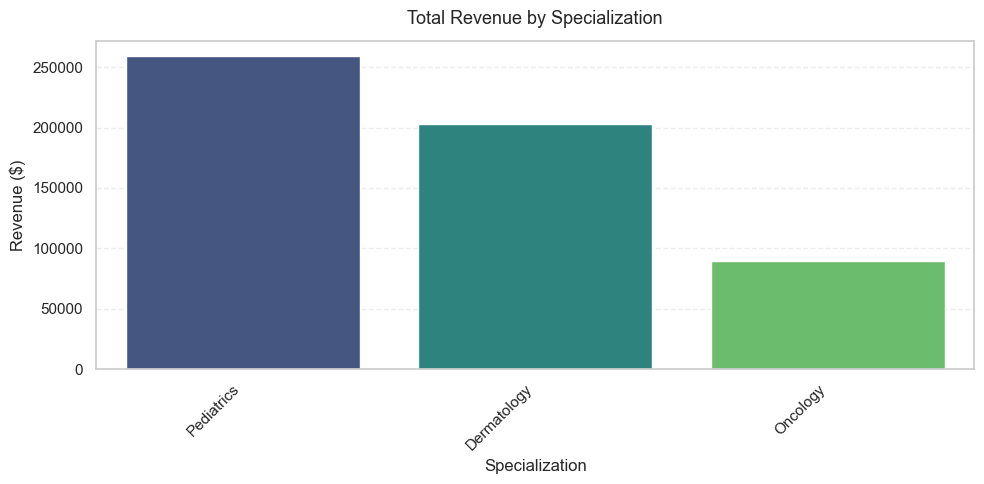

In [36]:
fig, ax = setup_plot(
    figsize=(10, 5),
    title="Total Revenue by Specialization",
    xlabel="Specialization",
    ylabel="Revenue ($)",
    rotate_x=True
)
sns.barplot(data=df_specialization_finance, x="specialization", y="total_revenue", palette="viridis", ax=ax)
finalize_plot(ax)


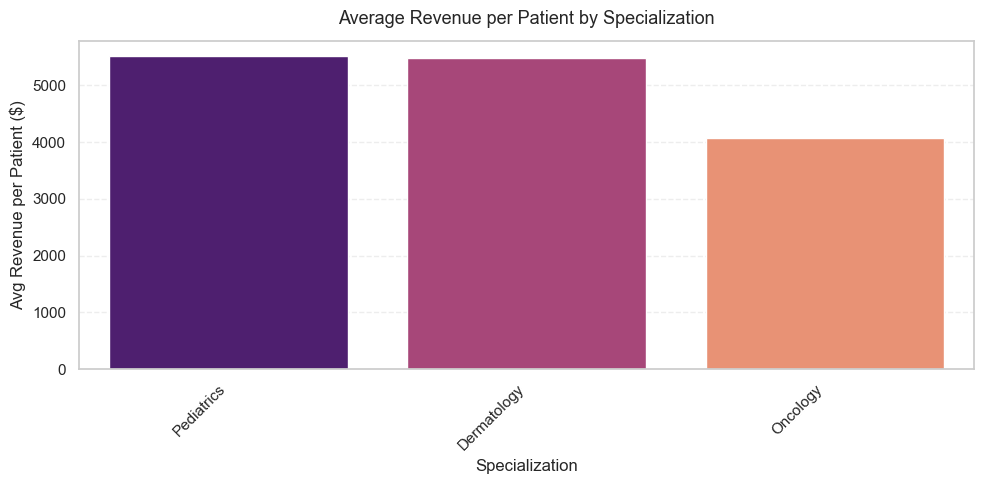

In [37]:
fig, ax = setup_plot(
    figsize=(10, 5),
    title="Average Revenue per Patient by Specialization",
    xlabel="Specialization",
    ylabel="Avg Revenue per Patient ($)",
    rotate_x=True
)
sns.barplot(data=df_specialization_finance, x="specialization", y="avg_revenue_per_patient", palette="magma", ax=ax)
finalize_plot(ax)


**Insight:** Specializations differ in both total contribution and per-patient value, providing a clear basis for service-line planning and resource allocation.


## Strategic Recommendations

1. **Stabilize collections (highest ROI):** Run a weekly aged-receivables review and tighten follow-up on Pending/Failed balances; segment high-cost encounters for earlier financial counseling.
2. **Rebalance physician access:** Reduce chronic overload on the highest-volume doctors by redistributing intake and follow-up slots; pair with specialty demand signals from visit reasons.
3. **Protect margin on concentrated service lines:** For treatment types with high unit cost and high revenue share, validate pricing, authorization quality, and supply utilization.
4. **Operational reliability:** Treat no-shows and cancellations as a throughput KPI—improve reminders, confirmation workflows, and same-day backfill rules.
5. **Executive monitoring:** Track a small monthly scorecard—appointments, billed revenue, collected revenue, collection rate—to connect operations and cash outcomes in one view.
